<a href="https://colab.research.google.com/github/jeffersonramelo/M-TODOS-QUANTITATIVOS/blob/main/Graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

dados=pd.read_csv('/content/graficosdados.csv', sep=';')
dados

,obstaculos,lucro1,lucro2
0,corrupcao,11,1
1,corrupcao,12,1
2,corrupcao,12,1
3,corrupcao,12,2
4,corrupcao,13,2
5,corrupcao,13,2
6,corrupcao,13,2
7,corrupcao,13,3
8,corrupcao,14,3
9,tributos,14,3


HISTOGRAMA SEM DIVISÃO EM CLASSES

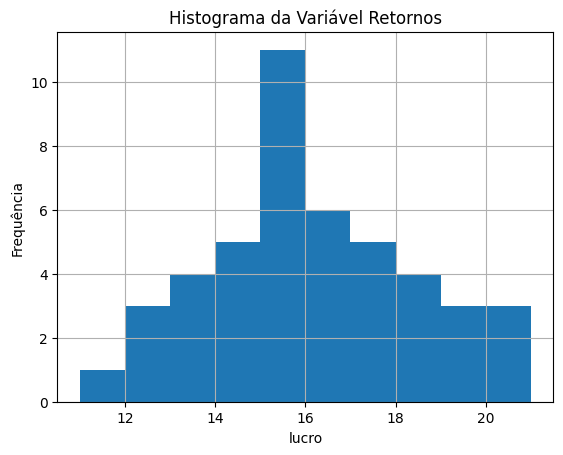

In [ ]:
import matplotlib.pyplot as plt

dados['lucro1'].hist()
plt.title('Histograma da Variável Retornos')
plt.xlabel('lucro')
plt.ylabel('Frequência')
plt.show()

HISTOGRAMA COM DIVISÃO EM CLASSES

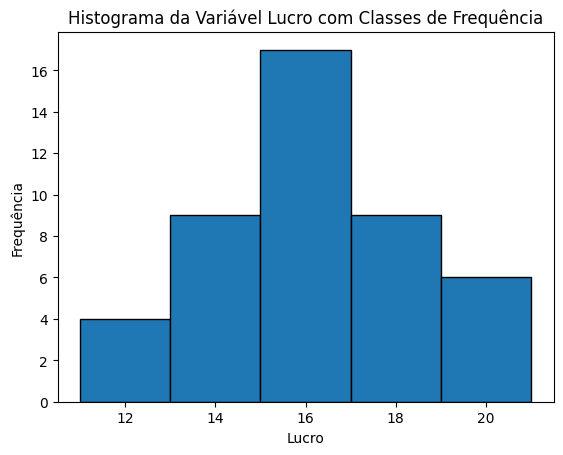

In [ ]:
import matplotlib.pyplot as plt

# Definir o número de classes ou deixar o matplotlib decidir automaticamente
# Por exemplo, 10 classes. Você pode ajustar este número.
plt.hist(dados['lucro1'], bins=5, edgecolor='black')
plt.title('Histograma da Variável Lucro com Classes de Frequência')
plt.xlabel('Lucro')
plt.ylabel('Frequência')
plt.show()

GRAFICO DE COLUNAS

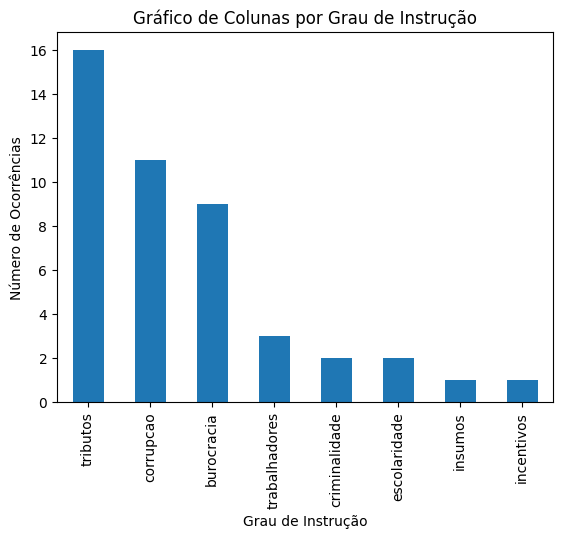

In [ ]:
import matplotlib.pyplot as plt

# Contar a frequência de cada grau de instrução
instrucao = dados['obstaculos'].value_counts()

# Criar o gráfico de colunas
instrucao.plot(kind='bar')
plt.title('Gráfico de Colunas por Grau de Instrução')
plt.xlabel('Grau de Instrução')
plt.ylabel('Número de Ocorrências')
plt.show()

GRAFICO DE BARRAS

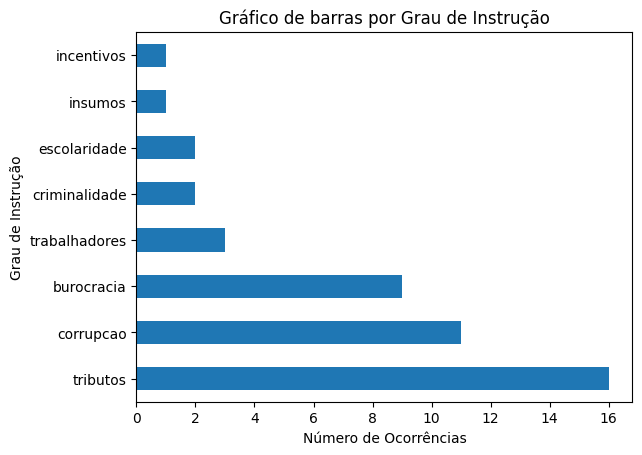

In [ ]:
import matplotlib.pyplot as plt

# Contar a frequência de cada grau de instrução
instrucao = dados['obstaculos'].value_counts()

# Criar o gráfico de colunas
instrucao.plot(kind='barh')
plt.title('Gráfico de barras por Grau de Instrução')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Grau de Instrução')
plt.show()

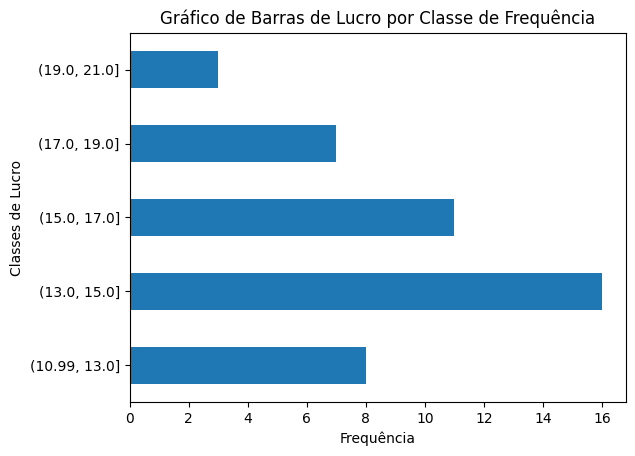

In [ ]:
# Criar as classes de frequência para a variável 'lucro'
lucro_classes = pd.cut(dados['lucro1'], bins=5)

# Contar a ocorrência de cada classe
lucro_classes = lucro_classes.value_counts().sort_index()

# Criar o gráfico de barras
lucro_classes.plot(kind='barh')
plt.title('Gráfico de Barras de Lucro por Classe de Frequência')
plt.xlabel('Frequência')
plt.ylabel('Classes de Lucro')
plt.show()

GRAFICO DE SETORES (PIZZA)

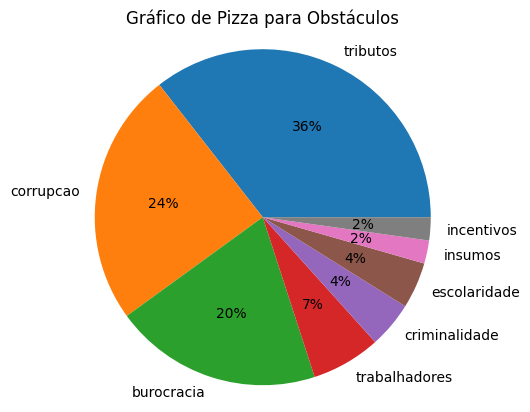

In [ ]:
import matplotlib.pyplot as plt

# Contar a frequência de cada obstáculo
obstaculos = dados['obstaculos'].value_counts()

# Criar o gráfico de pizza
plt.pie(obstaculos, labels=obstaculos.index, autopct='%1.0f%%')
plt.title('Gráfico de Pizza para Obstáculos')
plt.axis('equal') # Garante que o gráfico de pizza seja desenhado como um círculo
plt.show()

BOXBLOT

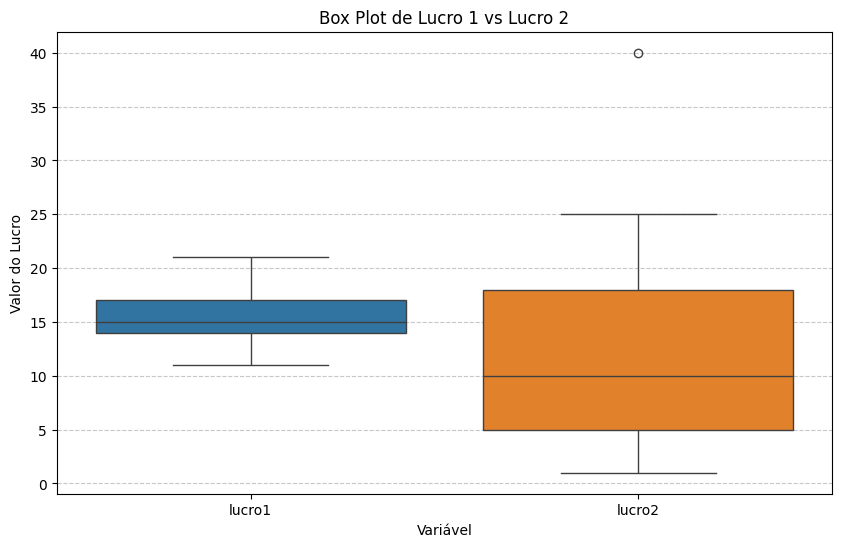

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar um DataFrame com as colunas 'lucro1' e 'lucro2'
df_lucros = dados[['lucro1', 'lucro2']]

# Usar seaborn para criar os box plots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_lucros)
plt.title('Box Plot de Lucro 1 vs Lucro 2')
plt.xlabel('Variável')
plt.ylabel('Valor do Lucro')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

GRAFICO DE DISPERSÃO

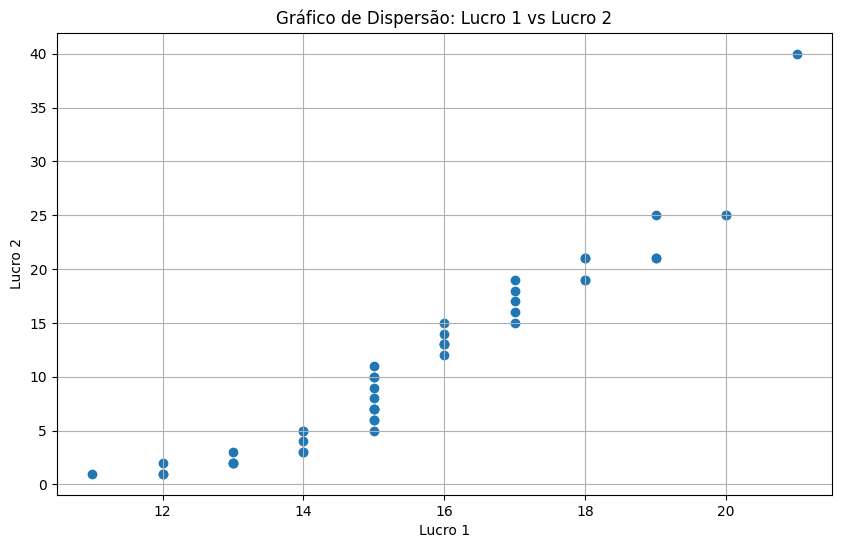

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(dados['lucro1'], dados['lucro2'])
plt.title('Gráfico de Dispersão: Lucro 1 vs Lucro 2')
plt.xlabel('Lucro 1')
plt.ylabel('Lucro 2')
plt.grid(True)
plt.show()

GRAFICO DE OGIVA

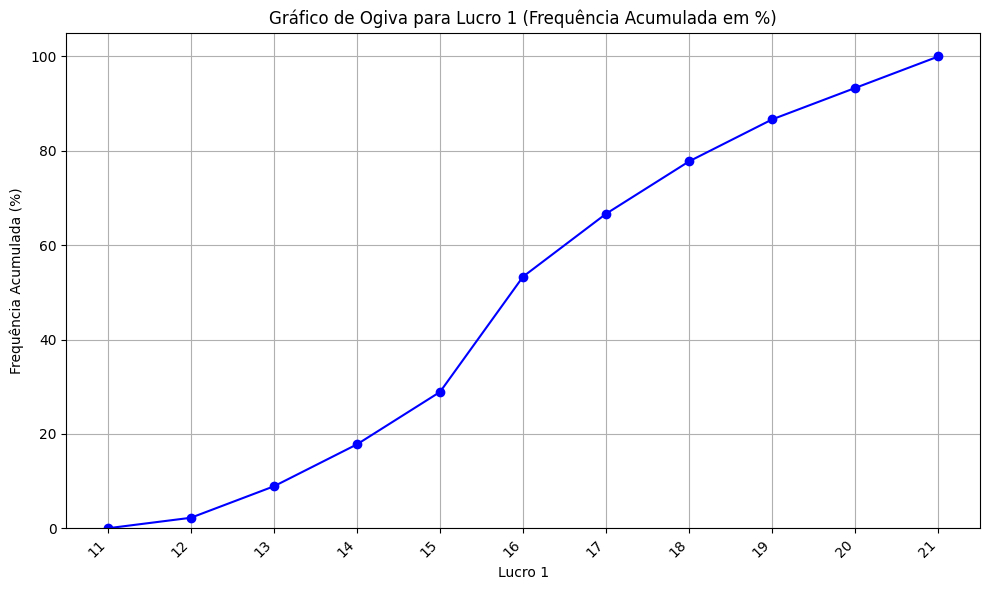

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Definir o número de bins ou deixar numpy decidir
bins = 10  # Você pode ajustar este número conforme necessário

# Calcular as frequências e as bordas dos bins
counts, bin_edges = np.histogram(dados['lucro1'], bins=bins)

# Calcular a frequência acumulada em porcentagem
total_count = len(dados['lucro1'])
cumulative_percentage = (np.cumsum(counts) / total_count) * 100

# Adicionar um ponto inicial para a ogiva começar do zero
x_values = [bin_edges[0]] + list(bin_edges[1:])
y_values = [0] + list(cumulative_percentage)

# Criar o gráfico de ogiva
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, marker='o', linestyle='-', color='blue')
plt.title('Gráfico de Ogiva para Lucro 1 (Frequência Acumulada em %)')
plt.xlabel('Lucro 1')
plt.ylabel('Frequência Acumulada (%)')
plt.grid(True)
plt.xticks(bin_edges, rotation=45, ha='right') # Rótulos do eixo x nas bordas dos bins
plt.ylim(0, 105) # Garantir que o eixo Y vá até um pouco mais de 100%
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

GRAFICO DE PARETO

/tmp/ipykernel_6258/1773548102.py:26: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



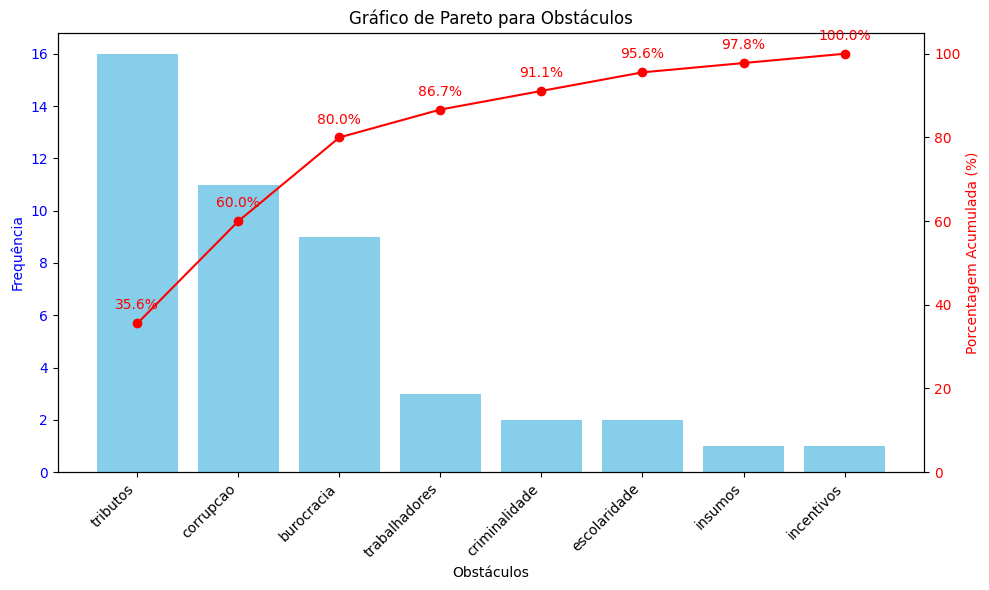

In [ ]:
# Calcular a frequência de cada obstáculo
contagem_obstaculos = dados['obstaculos'].value_counts()

# Calcular a porcentagem e a porcentagem acumulada
porcentagem = contagem_obstaculos / len(dados) * 100
porcentagem_acumulada = porcentagem.cumsum()

# Criar um DataFrame para facilitar o plot
pareto_data = pd.DataFrame({
    'Frequência': contagem_obstaculos,
    'Porcentagem': porcentagem,
    'Porcentagem Acumulada': porcentagem_acumulada
})

# Garantir que os dados estejam ordenados para o gráfico de Pareto
pareto_data = pareto_data.sort_values(by='Frequência', ascending=False)

# Criar o gráfico
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras de frequência
ax1.bar(pareto_data.index, pareto_data['Frequência'], color='skyblue')
ax1.set_xlabel('Obstáculos')
ax1.set_ylabel('Frequência', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(pareto_data.index, rotation=45, ha='right') # Rotacionar rótulos do eixo X

# Linha de porcentagem acumulada
ax2 = ax1.twinx() # Cria um segundo eixo y que compartilha o mesmo eixo x
ax2.plot(pareto_data.index, pareto_data['Porcentagem Acumulada'], color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentagem Acumulada (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105) # Ajustar o limite do eixo Y para a porcentagem

# Adicionar rótulos para a linha de porcentagem acumulada
for i, txt in enumerate(pareto_data['Porcentagem Acumulada']):
    ax2.annotate(f'{txt:.1f}%', (pareto_data.index[i], pareto_data['Porcentagem Acumulada'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.title('Gráfico de Pareto para Obstáculos')
fig.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()